# Questão 4

Com base na distribuição de energia da DCT2, a imagem é comprimida preservando
99.5%, 99.0%, 90.0%, 75.0% e 50.0% da energia total.


In [1]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Audio, display
from scipy.io import wavfile
from scipy.fft import dct, idct, fft, ifft, dctn, idctn
from PIL import Image

plt.style.use('seaborn-v0_8-whitegrid')

CWD = Path.cwd().resolve()
if (CWD / 'sosias.jpg').exists():
    PRACTICE_DIR = CWD
elif (CWD / 'pratica_4' / 'sosias.jpg').exists():
    PRACTICE_DIR = (CWD / 'pratica_4').resolve()
else:
    PRACTICE_DIR = CWD

DATA_DIR = (PRACTICE_DIR.parent / 'data').resolve()
AUDIO_PATH = DATA_DIR / 'handel.wav'
IMAGE_PATH = (PRACTICE_DIR / 'sosias.jpg').resolve()


In [2]:
def to_float_mono(signal):
    signal = np.asarray(signal)
    if signal.ndim > 1:
        signal = signal.mean(axis=1)

    signal = signal.astype(np.float64)
    peak = np.max(np.abs(signal))
    if peak > 0:
        signal = signal / peak
    return signal


def show_audio(signal, fs, label):
    signal = np.asarray(signal, dtype=np.float64)
    peak = np.max(np.abs(signal))
    if peak > 0:
        signal = signal / peak
    display(Audio(signal, rate=fs))
    print(label)


def mse(reference, estimate):
    reference = np.asarray(reference, dtype=np.float64)
    estimate = np.asarray(estimate, dtype=np.float64)
    return float(np.mean((reference - estimate) ** 2))


def display_rows(rows, float_digits=6):
    if not rows:
        print('Sem dados para exibir.')
        return

    headers = list(rows[0].keys())
    formatted_rows = []
    for row in rows:
        formatted = []
        for header in headers:
            value = row[header]
            if isinstance(value, float):
                formatted.append(f'{value:.{float_digits}f}')
            else:
                formatted.append(str(value))
        formatted_rows.append(formatted)

    widths = []
    for idx, header in enumerate(headers):
        content_width = max(len(row[idx]) for row in formatted_rows)
        widths.append(max(len(header), content_width))

    header_line = ' | '.join(header.ljust(widths[idx]) for idx, header in enumerate(headers))
    separator = '-+-'.join('-' * width for width in widths)
    print(header_line)
    print(separator)
    for row in formatted_rows:
        print(' | '.join(value.ljust(widths[idx]) for idx, value in enumerate(row)))


def select_by_energy(coeffs, keep_energy):
    coeffs = np.asarray(coeffs)
    energy = np.abs(coeffs) ** 2
    flat_energy = energy.ravel()
    order = np.argsort(flat_energy)[::-1]
    cumulative = np.cumsum(flat_energy[order])
    total_energy = cumulative[-1]
    threshold = keep_energy * total_energy
    keep_count = int(np.searchsorted(cumulative, threshold, side='left')) + 1

    mask = np.zeros(coeffs.size, dtype=bool)
    mask[order[:keep_count]] = True
    mask = mask.reshape(coeffs.shape)

    compressed = np.zeros_like(coeffs)
    compressed[mask] = coeffs[mask]
    retained = float(np.sum(np.abs(compressed) ** 2) / total_energy)
    return compressed, keep_count, retained, mask


def compress_audio_dct(signal, keep_energy):
    coeffs = dct(signal, norm='ortho')
    compressed, keep_count, retained, _ = select_by_energy(coeffs, keep_energy)
    reconstructed = idct(compressed, norm='ortho')
    return {
        'coeffs': coeffs,
        'compressed_coeffs': compressed,
        'reconstructed': reconstructed,
        'keep_count': keep_count,
        'retained_energy': retained,
    }


def compress_audio_fft(signal, keep_energy):
    coeffs = fft(signal)
    compressed, keep_count, retained, _ = select_by_energy(coeffs, keep_energy)
    reconstructed = np.real(ifft(compressed))
    return {
        'coeffs': coeffs,
        'compressed_coeffs': compressed,
        'reconstructed': reconstructed,
        'keep_count': keep_count,
        'retained_energy': retained,
    }


def plot_time_and_error(original, reconstructed, fs, title):
    t = np.arange(len(original)) / fs
    fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
    axes[0].plot(t, original, label='Original', alpha=0.8)
    axes[0].plot(t, reconstructed, label='Reconstruido', alpha=0.7)
    axes[0].set_title(title)
    axes[0].set_ylabel('Amplitude')
    axes[0].legend()

    axes[1].plot(t, original - reconstructed, color='tab:red')
    axes[1].set_title('Erro de reconstrução')
    axes[1].set_xlabel('Tempo (s)')
    axes[1].set_ylabel('Erro')
    plt.tight_layout()
    plt.show()
def load_gray_image(path):
    image = Image.open(path).convert('L')
    array = np.asarray(image, dtype=np.float64) / 255.0
    return image, array


def compress_image_dct(image_array, keep_energy):
    coeffs = dctn(image_array, norm='ortho')
    compressed, keep_count, retained, mask = select_by_energy(coeffs, keep_energy)
    reconstructed = idctn(compressed, norm='ortho')
    reconstructed = np.clip(reconstructed, 0.0, 1.0)
    return {
        'coeffs': coeffs,
        'compressed_coeffs': compressed,
        'reconstructed': reconstructed,
        'keep_count': keep_count,
        'retained_energy': retained,
        'mask': mask,
    }


def blockwise_dct_compression(image_array, block_size, keep_energy):
    h, w = image_array.shape
    pad_h = (block_size - h % block_size) % block_size
    pad_w = (block_size - w % block_size) % block_size
    padded = np.pad(image_array, ((0, pad_h), (0, pad_w)), mode='edge')
    reconstructed = np.zeros_like(padded)
    total_kept = 0
    total_coeffs = padded.size

    for i in range(0, padded.shape[0], block_size):
        for j in range(0, padded.shape[1], block_size):
            block = padded[i:i + block_size, j:j + block_size]
            coeffs = dctn(block, norm='ortho')
            compressed, keep_count, _, _ = select_by_energy(coeffs, keep_energy)
            reconstructed[i:i + block_size, j:j + block_size] = idctn(compressed, norm='ortho')
            total_kept += keep_count

    reconstructed = reconstructed[:h, :w]
    reconstructed = np.clip(reconstructed, 0.0, 1.0)
    return {
        'reconstructed': reconstructed,
        'keep_count': total_kept,
        'compression_ratio': total_kept / total_coeffs,
    }


In [3]:
_, image = load_gray_image(IMAGE_PATH)

keep_levels = [0.995, 0.99, 0.90, 0.75, 0.50]
results = {}
rows = []

for keep in keep_levels:
    result = compress_image_dct(image, keep)
    key = f'{keep * 100:.1f}%'
    results[key] = result
    rows.append(
        {
            'Energia preservada': key,
            'Coeficientes mantidos': result['keep_count'],
            'Percentual de coeficientes': 100 * result['keep_count'] / image.size,
            'Energia efetiva (%)': 100 * result['retained_energy'],
            'MSE': mse(image, result['reconstructed']),
        }
    )

display_rows(rows, float_digits=8)


Energia preservada | Coeficientes mantidos | Percentual de coeficientes | Energia efetiva (%) | MSE       
-------------------+-----------------------+----------------------------+---------------------+-----------
99.5%              | 18078                 | 2.24850746                 | 99.50000068         | 0.00198419
99.0%              | 5578                  | 0.69378109                 | 99.00008446         | 0.00396590
90.0%              | 30                    | 0.00373134                 | 90.01453440         | 0.03918114
75.0%              | 2                     | 0.00024876                 | 77.72704961         | 0.08848303
50.0%              | 1                     | 0.00012438                 | 71.14097104         | 0.11464733


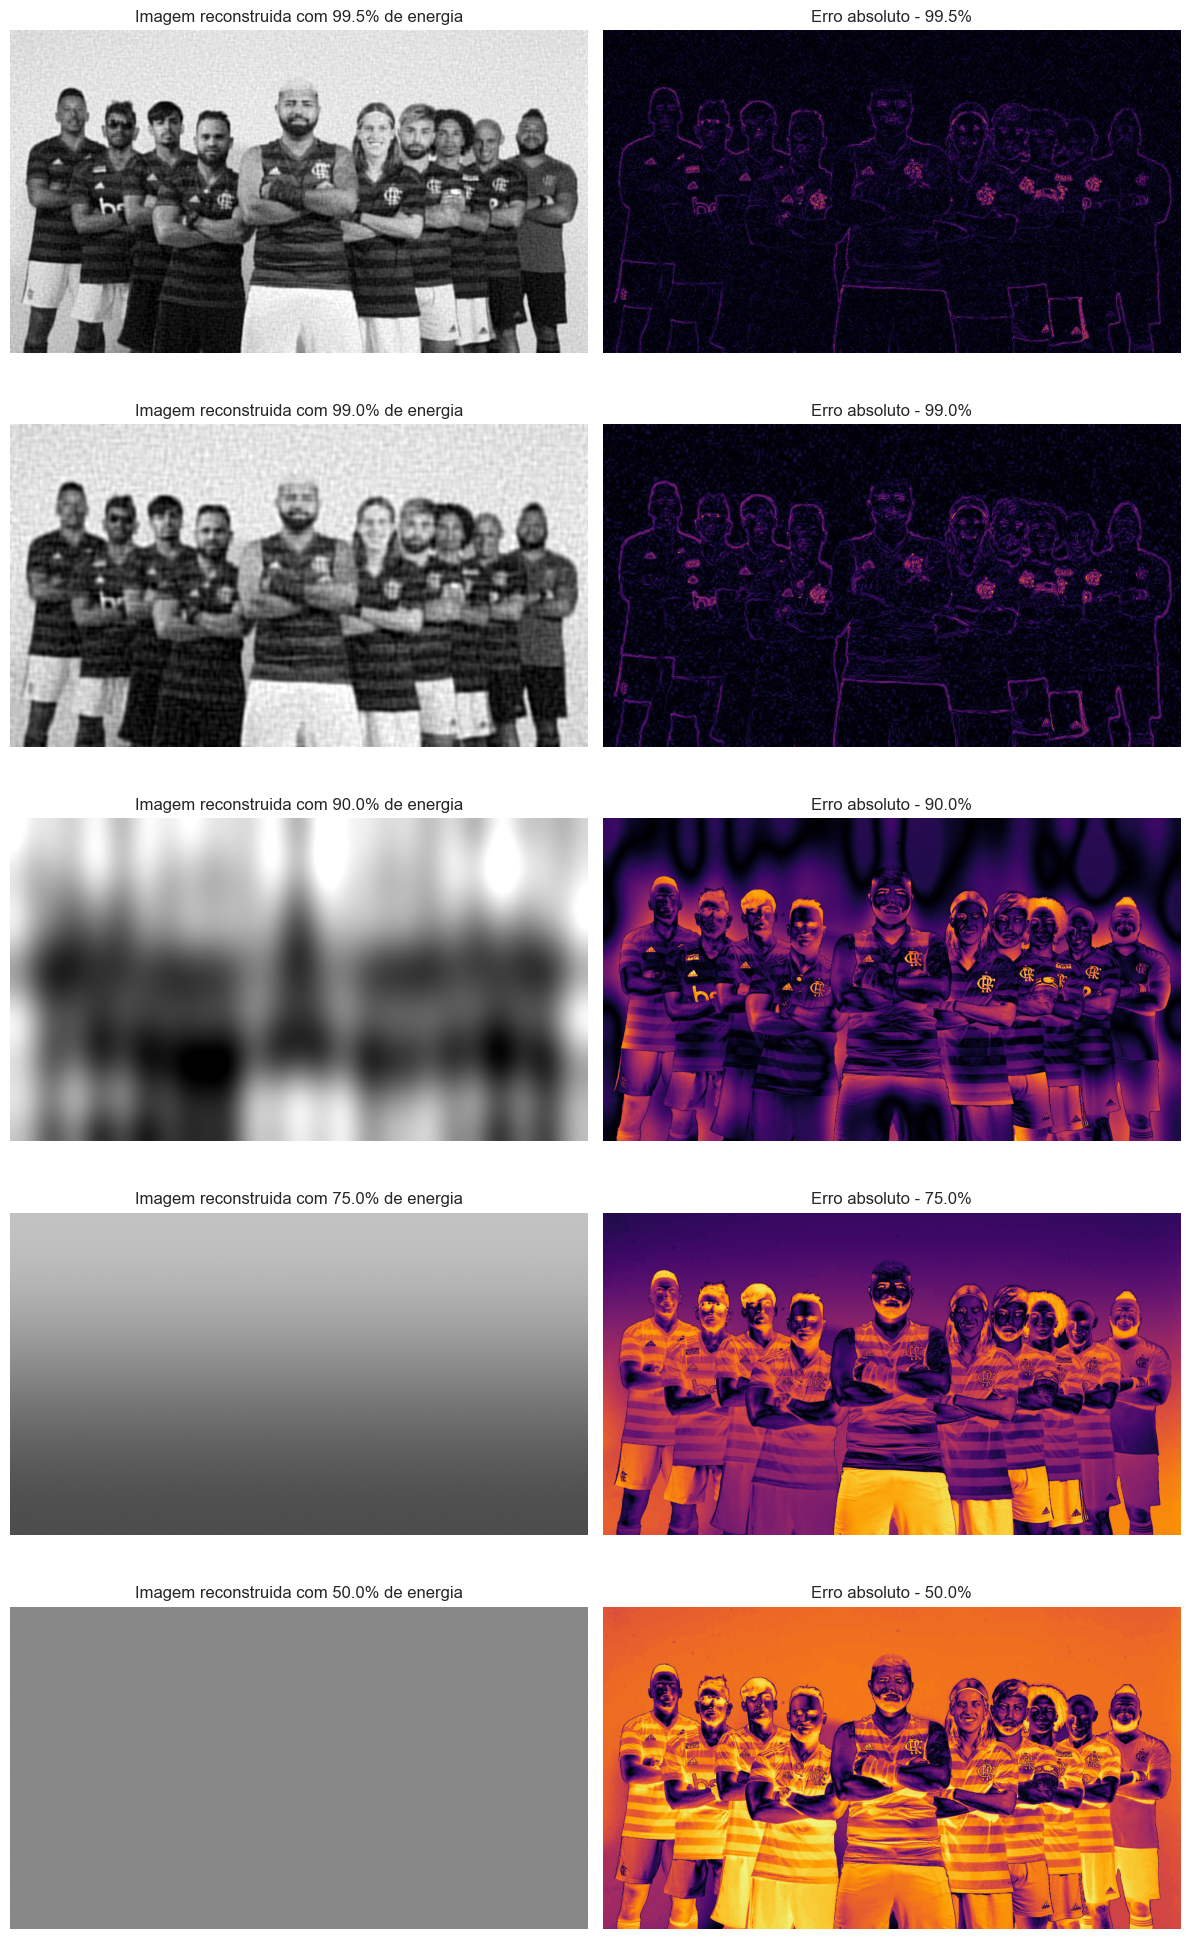

In [4]:
fig, axes = plt.subplots(len(results), 2, figsize=(12, 4 * len(results)))

for idx, (label, result) in enumerate(results.items()):
    axes[idx, 0].imshow(result['reconstructed'], cmap='gray', vmin=0, vmax=1)
    axes[idx, 0].set_title(f'Imagem reconstruida com {label} de energia')
    axes[idx, 0].axis('off')

    diff = np.abs(image - result['reconstructed'])
    axes[idx, 1].imshow(diff, cmap='inferno')
    axes[idx, 1].set_title(f'Erro absoluto - {label}')
    axes[idx, 1].axis('off')

plt.tight_layout()
plt.show()


## Comentários

- Com 99.5% e 99.0% de energia preservada, a perda visual tende a ser pequena.
- Em 90.0%, a imagem ainda permanece reconhecível, mas já aparecem perdas de textura fina.
- Em 75.0% e 50.0%, os borramentos e artefatos ficam mais evidentes, embora a estrutura global da imagem ainda seja mantida.
